In [1]:
from pathlib import Path

import pandas as pd
import scanpy as sc
import anndata as ad
from scipy import sparse

# Set Base directory to the location of this script
BASE = Path.cwd()

# Set working directory to the location of this script 
# data_dir = BASE / 'h5s_common_directory'
data_dir = BASE / 'h5s_common_directory_WIP'

# Print contents of the data directory for verification
print(f"Contents of data directory ({data_dir}):")
for item in data_dir.iterdir():
    print(item.name)


Contents of data directory (c:\Users\ankit\Documents\scFM\train_data\h5s_common_directory_WIP):
GSE159977.h5ad
GSE174748.h5ad
GSE185477.h5ad
GSE189600.h5ad
GSE190487.h5ad
GSE192740.h5ad
GSE202379.h5ad
GSE212837.h5ad
GSE270488.h5ad


In [2]:
# Read in each h5ad file with the Anndata object variable name being it's file name without the extension and store in dictionary
adata_dict = {}

for h5ad_file in data_dir.glob('*.h5ad'):
    adata_name = h5ad_file.stem  # Get file name without extension
    adata_dict[adata_name] = ad.read_h5ad(h5ad_file)  # Read h5ad file and store in dictionary



c:\Users\ankit\miniconda3\envs\scanpy\Lib\site-packages\anndata\_core\anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [39]:

# For unique values in the sample column, print the corresponding value
unique_titles = adata_dict["GSE270488"].obs["sequencing_origin"].unique()
print("Unique titles in the sequencing_origin column:")
for title in unique_titles:
    print(f"Title: {title}")


Unique titles in the sequencing_origin column:
Title: in_house


In [35]:
# Read in temp.csv file to get the mapping of gsm_id to characteristics: shortFileName
temp_df = pd.read_csv(BASE / 'temp.csv')
print(temp_df.head())

# Add gsm_id column to the obs dataframe of the GSE192740 anndata object using the mapping from temp_df
adata_dict["GSE192740"].obs["gsm_id"] = adata_dict["GSE192740"].obs["characteristics: shortFileName"].map(temp_df.set_index("characteristics: shortFileName")["gsm_id"])

print(adata_dict["GSE192740"].obs[["characteristics: shortFileName", "gsm_id"]].head())

  characteristics: shortFileName      gsm_id
0                         CISE06  GSM5764338
1                         CISE07  GSM5764341
2                         CISE08  GSM5764344
3                         CISE09  GSM5764346
4                          CS101  GSM5764386
  characteristics: shortFileName      gsm_id
0                         CISE06  GSM5764338
1                         CISE06  GSM5764338
2                         CISE06  GSM5764338
3                         CISE06  GSM5764338
4                         CISE06  GSM5764338


In [16]:
# Save each anndata object in the dictionary to a new h5ad file with the same GSE file name in the directory called 'h5s_common_directory_WIP'

output_dir = BASE / 'h5s_common_directory_WIP'
output_dir.mkdir(exist_ok=True)  # Create output directory if it doesn't exist
for name, adata in adata_dict.items():
    output_file = output_dir / f"{name}.h5ad"
    adata.write_h5ad(output_file)
    print(f"Saved {name} to {output_file}")

Saved GSE159977 to c:\Users\ankit\Documents\scFM\train_data\h5s_common_directory_WIP\GSE159977.h5ad
Saved GSE174748 to c:\Users\ankit\Documents\scFM\train_data\h5s_common_directory_WIP\GSE174748.h5ad
Saved GSE185477 to c:\Users\ankit\Documents\scFM\train_data\h5s_common_directory_WIP\GSE185477.h5ad
Saved GSE189600 to c:\Users\ankit\Documents\scFM\train_data\h5s_common_directory_WIP\GSE189600.h5ad
Saved GSE190487 to c:\Users\ankit\Documents\scFM\train_data\h5s_common_directory_WIP\GSE190487.h5ad
Saved GSE192740 to c:\Users\ankit\Documents\scFM\train_data\h5s_common_directory_WIP\GSE192740.h5ad
Saved GSE202379 to c:\Users\ankit\Documents\scFM\train_data\h5s_common_directory_WIP\GSE202379.h5ad
Saved GSE212837 to c:\Users\ankit\Documents\scFM\train_data\h5s_common_directory_WIP\GSE212837.h5ad
Saved GSE270488 to c:\Users\ankit\Documents\scFM\train_data\h5s_common_directory_WIP\GSE270488.h5ad


In [ ]:
# Relabel the gsm column in the obs dataframe of the GSE189600 anndata object to gsm_id
#adata_dict["GSE192740"].obs.rename(columns={"sample_id": "gsm_id"}, inplace=True)

In [3]:
# Print each adata object
for name, adata in adata_dict.items():
    print(f"Anndata object: {name}")
    print(adata)
    print("\n")

Anndata object: GSE159977
AnnData object with n_obs × n_vars = 10923732 × 33694
    obs: 'gsm_id', 'patient_id', 'sample_desc', 'condition', 'tissue', 'treatment', 'sample_type', 'batch', 'assay_type', 'n_counts', 'n_genes', 'dataset'
    layers: 'counts'


Anndata object: GSE174748
AnnData object with n_obs × n_vars = 4524728 × 33538
    obs: 'barcode', 'patient_id', 'condition', 'gsm_id', 'batch', 'assay_type', 'n_counts', 'n_genes', 'dataset'
    layers: 'counts'


Anndata object: GSE185477
AnnData object with n_obs × n_vars = 9560531 × 45068
    obs: 'sample_desc', 'patient_id', 'assay_type', 'prep', 'gsm_id', 'condition', 'dataset', 'batch', 'n_counts', 'n_genes', 'sex', 'cause_of_death'
    var: 'gene_symbol'
    layers: 'counts'


Anndata object: GSE189600
AnnData object with n_obs × n_vars = 65879 × 36601
    obs: 'gsm_id', 'patient_id', 'condition', 'species', 'assay_type', 'dataset', 'batch', 'sex', 'age', 'ethnicity', 'cause_of_death', 'alcohol_use', 'n_counts', 'n_genes'
  

In [17]:
# Create a csv file with the following structure: Each row is the anndata object name, then the various obs columns it has. The following 5 rows are the first 5 unique values of each obs column. Keep one column in the csv as one obs column and then move one column to the right for the next obs column. Then skip a line and go to the next anndata object. The csv file should be called 'adata_obs_summary.csv' and should be saved in the same directory as this script. 
summary_file = BASE / 'adata_obs_summary.csv'
with open(summary_file, 'w') as f:
    for name, adata in adata_dict.items():
        f.write(f"{name}\n")  # Write the anndata object name
        obs_columns = adata.obs.columns
        f.write(",".join(obs_columns) + "\n")  # Write the obs column names
        for i in range(5):  # Write the first 5 unique values of each obs column
            row_values = []
            for col in obs_columns:
                unique_values = adata.obs[col].unique()
                if i < len(unique_values):
                    row_values.append(str(unique_values[i]))
                else:
                    row_values.append("")  # If there are less than 5 unique values, fill with empty string
            f.write(",".join(row_values) + "\n")
        f.write("\n")  # Add a blank line after each anndata object

print(f"File saved: {summary_file}")

File saved: c:\Users\ankit\Documents\scFM\train_data\adata_obs_summary.csv


GSE159977 Modifications 

In [16]:
# All changes refer to GSE159977 anndata object
# Change title column to sample_desc
adata_dict["GSE159977"].obs.rename(columns={"title": "sample_desc"}, inplace=True)

# Change pathology column to condition
adata_dict["GSE159977"].obs.rename(columns={"pathology": "condition"}, inplace=True)

# Change NASH value in condition column to MASH
adata_dict["GSE159977"].obs["condition"] = adata_dict["GSE159977"].obs["condition"].replace("NASH", "MASH")

# Change Healthy Human Liver value in condition column to Healthy
adata_dict["GSE159977"].obs["condition"] = adata_dict["GSE159977"].obs["condition"].replace("Healthy Human Liver", "Healthy")

# View adata
print(adata_dict["GSE159977"])


AnnData object with n_obs × n_vars = 10923732 × 33694
    obs: 'gsm_id', 'patient_id', 'sample_desc', 'condition', 'tissue', 'treatment', 'sample_type', 'batch', 'assay_type', 'n_counts', 'n_genes'


C:\Users\ankit\AppData\Local\Temp\ipykernel_26556\1308988599.py:9: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata_dict["GSE159977"].obs["condition"] = adata_dict["GSE159977"].obs["condition"].replace("NASH", "MASH")
C:\Users\ankit\AppData\Local\Temp\ipykernel_26556\1308988599.py:12: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata_dict["GSE159977"].obs["condition"] = adata_dict["GSE159977"].obs["condition"].replace("Healthy Human Liver", "Healthy")


In [18]:
# Change Liver Biopsy value in tissue to liver
adata_dict["GSE159977"].obs["tissue"] = adata_dict["GSE159977"].obs["tissue"].replace("Liver Biopsy", "liver")

C:\Users\ankit\AppData\Local\Temp\ipykernel_16620\1581367615.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata_dict["GSE159977"].obs["tissue"] = adata_dict["GSE159977"].obs["tissue"].replace("Liver Biopsy", "liver")


In [9]:
print(adata_dict["GSE159977"].obs["condition"].unique())

['Boderline NASH', 'MASH', 'Healthy']
Categories (3, object): ['Boderline NASH', 'Healthy', 'MASH']


In [10]:
adata_dict["GSE159977"].obs["condition"] = adata_dict["GSE159977"].obs["condition"].replace("Boderline NASH", "Borderline MASH")

C:\Users\ankit\AppData\Local\Temp\ipykernel_25500\3166121219.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata_dict["GSE159977"].obs["condition"] = adata_dict["GSE159977"].obs["condition"].replace("Boderline NASH", "Borderline MASH")


In [11]:
# Save GSE159977 anndata object to a new h5ad file with the same GSE file name in the directory called 'h5s_common_directory_WIP'
output_dir = BASE / 'h5s_common_directory_WIP'
output_dir.mkdir(exist_ok=True)  # Create output directory if it doesn't exist
output_file = output_dir / "GSE159977.h5ad"
adata_dict["GSE159977"].write_h5ad(output_file)

GSE174748 changes

In [17]:
# All changes refer to GSE174748 anndata object
# Change sample column to patient_id
adata_dict["GSE174748"].obs.rename(columns={"sample": "patient_id"}, inplace=True)

# Change nafld value in condition column to MASLD
adata_dict["GSE174748"].obs["condition"] = adata_dict["GSE174748"].obs["condition"].replace("nafld", "MASLD")

# Change "healthy" value in condition column to Healthy
adata_dict["GSE174748"].obs["condition"] = adata_dict["GSE174748"].obs["condition"].replace("healthy", "Healthy")

# View adata
print(adata_dict["GSE174748"])


AnnData object with n_obs × n_vars = 4524728 × 33538
    obs: 'barcode', 'patient_id', 'condition', 'gsm_id', 'batch', 'assay_type', 'n_counts', 'n_genes'


C:\Users\ankit\AppData\Local\Temp\ipykernel_26556\1709001172.py:6: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata_dict["GSE174748"].obs["condition"] = adata_dict["GSE174748"].obs["condition"].replace("nafld", "MASLD")
C:\Users\ankit\AppData\Local\Temp\ipykernel_26556\1709001172.py:9: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata_dict["GSE174748"].obs["condition"] = adata_dict["GSE174748"].obs["condition"].replace("healthy", "Healthy")


GSE185477 Changes

In [18]:
# All changes refer to GSE185477 anndata object
# Change donor column to patient_id
adata_dict["GSE185477"].obs.rename(columns={"donor": "patient_id"}, inplace=True)

# Change sample_title column to sample_desc
adata_dict["GSE185477"].obs.rename(columns={"sample_title": "sample_desc"}, inplace=True)

# Change "Sex" column to "sex"
adata_dict["GSE185477"].obs.rename(columns={"Sex": "sex"}, inplace=True)

# Change "Cause_of_death" column to "cause_of_death
adata_dict["GSE185477"].obs.rename(columns={"Cause_of_death": "cause_of_death"}, inplace=True)

# View adata
print(adata_dict["GSE185477"])


AnnData object with n_obs × n_vars = 9560531 × 45068
    obs: 'sample_desc', 'patient_id', 'assay_type', 'prep', 'gsm_id', 'condition', 'dataset', 'batch', 'n_counts', 'n_genes', 'sex', 'cause_of_death'
    var: 'gene_symbol'
    layers: 'counts'


GSE189600 changes

In [19]:
# All changes refer to GSE189600 anndata object
# Change sample_name column to patient_id
adata_dict["GSE189600"].obs.rename(columns={"sample_name": "patient_id"}, inplace=True)

# Change NASH value in condition to MASH
adata_dict["GSE189600"].obs["condition"] = adata_dict["GSE189600"].obs["condition"].replace("NASH", "MASH")

# Change "healthy" value in condition column to Healthy
adata_dict["GSE189600"].obs["condition"] = adata_dict["GSE189600"].obs["condition"].replace("healthy", "Healthy")


# Change "Cause_of_death" column to "cause_of_death
adata_dict["GSE189600"].obs.rename(columns={"Cause_of_death": "cause_of_death"}, inplace=True)

# View adata
print(adata_dict["GSE189600"])


AnnData object with n_obs × n_vars = 65879 × 36601
    obs: 'gsm_id', 'patient_id', 'condition', 'species', 'assay_type', 'dataset', 'batch', 'sex', 'age', 'ethnicity', 'cause_of_death', 'alcohol_use', 'n_counts', 'n_genes'
    var: 'gene_ids', 'gene_symbols'
    layers: 'counts'


C:\Users\ankit\AppData\Local\Temp\ipykernel_26556\1869225398.py:6: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata_dict["GSE189600"].obs["condition"] = adata_dict["GSE189600"].obs["condition"].replace("NASH", "MASH")
C:\Users\ankit\AppData\Local\Temp\ipykernel_26556\1869225398.py:9: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata_dict["GSE189600"].obs["condition"] = adata_dict["GSE189600"].obs["condition"].replace("healthy", "Healthy")


In [40]:
# View alcohol_use values in GSE189600
print(adata_dict["GSE189600"].obs["alcohol_use"].unique())

[NaN, 'No']
Categories (1, object): ['No']


GSE190487 Changes

In [21]:
# All changes refer to GSE190487 anndata object
# Change disease column to condition
adata_dict["GSE190487"].obs.rename(columns={"disease": "condition"}, inplace=True)

# Change NAFLD value in condition to MASLD
adata_dict["GSE190487"].obs["condition"] = adata_dict["GSE190487"].obs["condition"].replace("NAFLD", "MASLD")

# Change study column to dataset
adata_dict["GSE190487"].obs.rename(columns={"study": "dataset"}, inplace=True)

# View adata
print(adata_dict["GSE190487"])


AnnData object with n_obs × n_vars = 810280 × 33538
    obs: 'gsm_id', 'dataset', 'condition', 'tissue', 'assay_type', 'n_counts', 'n_genes'
    var: 'gene_symbol', 'feature_type'
    layers: 'counts'


In [52]:
# Add patient_id column to GSE190487 anndata object by extracting the patient id gsm_id, removing the GSM and replace with PT-
adata_dict["GSE190487"].obs["patient_id"] = adata_dict["GSE190487"].obs["gsm_id"].str.replace("GSM", "PT-")

In [53]:
# Save adata_dict["GSE190487"] to a new h5ad file with the same GSE file name in the directory called 'h5s_common_directory_WIP'
output_dir = BASE / 'h5s_common_directory_WIP'
output_dir.mkdir(exist_ok=True)  # Create output directory if it doesn't exist
output_file = output_dir / "GSE190487.h5ad"
adata_dict["GSE190487"].write_h5ad(output_file)
print(f"Saved GSE190487 to {output_file}")

Saved GSE190487 to c:\Users\ankit\Documents\scFM\train_data\h5s_common_directory_WIP\GSE190487.h5ad


GSE192740 Changes (NEED TO ADD MASH/MASLD/Healthy DIAGNOSIS SOMEHOW)

In [113]:
# Read in 192740 anndata object from the h5ad file directory h5s_common_directory - April 14th update
output_file = BASE / 'h5s_common_directory' / "GSE192740.h5ad"
adata_dict["GSE192740"] = ad.read_h5ad(output_file)
print(adata_dict["GSE192740"])


AnnData object with n_obs × n_vars = 102004 × 32738
    obs: 'Sample name', 'title', 'source name', 'organism', 'characteristics: shortFileName', 'characteristics: strain', 'characteristics: platform', 'characteristics: digestion method', 'characteristics: number of added ABs', 'characteristics: number of cells', 'molecule', 'description', 'sample_class', 'assay_type', 'shortFileName', 'sample_group', 'gsm_id'


In [114]:
# Drop gsm_id column from the obs dataframe of the GSE192740 anndata object
adata_dict["GSE192740"].obs.drop(columns=["gsm_id"], inplace=True)

In [115]:
# Read in ./GSE192740/meta/fixed_patient_table_trimmed.csv
meta_target = pd.read_csv(BASE / "GSE192740" / "meta" / "fixed_patient_table_trimmed.csv")
#print(meta_target.head())
meta_target.set_index("characteristics: shortFileName", inplace=True)
# Merge meta_target with the obs dataframe of the GSE192740 anndata object using the characteristics: shortFileName
adata_dict["GSE192740"].obs = adata_dict["GSE192740"].obs.join(meta_target, on="characteristics: shortFileName", how="left")



In [107]:
print(adata_dict["GSE192740"].obs.head())

                                         Sample name title source name  \
CS110_AAACCCAAGGTATCTC-1-0  Liver_CD45+ Cells_ Human   H22       Liver   
CS110_AAACCCACACGGTGTC-1-0  Liver_CD45+ Cells_ Human   H22       Liver   
CS110_AAACCCACAGCTGAGA-1-0  Liver_CD45+ Cells_ Human   H22       Liver   
CS110_AAACCCACAGTCAGTT-1-0  Liver_CD45+ Cells_ Human   H22       Liver   
CS110_AAACCCACATTGCAAC-1-0  Liver_CD45+ Cells_ Human   H22       Liver   

                           organism characteristics: shortFileName  \
CS110_AAACCCAAGGTATCTC-1-0    Human                          CS110   
CS110_AAACCCACACGGTGTC-1-0    Human                          CS110   
CS110_AAACCCACAGCTGAGA-1-0    Human                          CS110   
CS110_AAACCCACAGTCAGTT-1-0    Human                          CS110   
CS110_AAACCCACATTGCAAC-1-0    Human                          CS110   

                           characteristics: strain characteristics: platform  \
CS110_AAACCCAAGGTATCTC-1-0                     nan    

In [116]:
values = adata_dict["GSE192740"].obs["title"].unique()
for value in values:
    print(value, end=" ")

print("\n")
values = adata_dict["GSE192740"].obs["patient_id"].unique()
for value in values:
    print(value, end=" ")

H22 H23 H25 H04 H10 H14 H33 H30 H32 H37 H38 

H22 H23 H25 H04 H10 H14 H33 H30 H32 H37 H38 

In [117]:
# All changes refer to GSE192740 anndata object
# Drop title column
adata_dict["GSE192740"].obs.drop(columns=["title"], inplace=True)

# Change Gender column to sex
adata_dict["GSE192740"].obs.rename(columns={"Gender": "sex"}, inplace=True)

# Change female to F and male to M
adata_dict["GSE192740"].obs["sex"] = adata_dict["GSE192740"].obs["sex"].replace({"female": "F", "male": "M"})

# Change Age column to age
adata_dict["GSE192740"].obs.rename(columns={"Age": "age"}, inplace=True)

# Remove y suffix from age column entries that start with a number (ie ignore unknown values) and convert to numeric
adata_dict["GSE192740"].obs["age"] = pd.to_numeric(adata_dict["GSE192740"].obs["age"].str.replace("y", ""), errors='coerce')

# Change Weight column to weight_kg
adata_dict["GSE192740"].obs.rename(columns={"Weight": "weight_kg"}, inplace=True)

# Change Height column to height_cm
adata_dict["GSE192740"].obs.rename(columns={"Height": "height_cm"}, inplace=True)

# Change any remaining columns that have capitalized names to lowercase
adata_dict["GSE192740"].obs.rename(columns={col: col.lower() for col in adata_dict["GSE192740"].obs.columns}, inplace=True)

# View adata
print(adata_dict["GSE192740"])

AnnData object with n_obs × n_vars = 102004 × 32738
    obs: 'sample name', 'source name', 'organism', 'characteristics: shortfilename', 'characteristics: strain', 'characteristics: platform', 'characteristics: digestion method', 'characteristics: number of added abs', 'characteristics: number of cells', 'molecule', 'description', 'sample_class', 'assay_type', 'shortfilename', 'sample_group', 'patient_id', 'biopsy_used_for ', 'sex', 'age', 'weight_kg', 'height_cm', 'reason_for_hospitalization', 'procedure', 'concomitant_medication', 'concomitant_disorders_operations', 'alcohol_intake', 'steatosis', 'fibrosis', 'cardiometabolic_func_needed', 'condition', 'bmi', 'gsm_id'


In [118]:
# Find unique values of alcohol_intake column in GSE192740 anndata object
print(adata_dict["GSE192740"].obs["alcohol_intake"].unique())

# Create new obs alcohol_use column. It will be Unknown if alcohol_intake is Unknown, Yes if alcohol_intake is anything other than Unknown or No, and No if alcohol_intake is No.
def categorize_alcohol_use(intake):
    if intake == "Unknown":
        return "Unknown"
    elif intake == "No":
        return "No"
    else:
        return "Yes"
    
adata_dict["GSE192740"].obs["alcohol_use"] = adata_dict["GSE192740"].obs["alcohol_intake"].apply(categorize_alcohol_use)
print(adata_dict["GSE192740"].obs["alcohol_intake"].unique())
print(adata_dict["GSE192740"].obs["alcohol_use"].unique())

['Unknown' 'No' '1-2 standard units daily' '4 standard units daily']
['Unknown' 'No' '1-2 standard units daily' '4 standard units daily']
['Unknown' 'No' 'Yes']


In [78]:
# Make bmi obs column in adata object string
adata_dict["GSE192740"].obs["bmi"] = adata_dict["GSE192740"].obs["bmi"].astype(str)


In [119]:
print(adata_dict["GSE192740"].obs.head())

                                         sample name source name organism  \
CS110_AAACCCAAGGTATCTC-1-0  Liver_CD45+ Cells_ Human       Liver    Human   
CS110_AAACCCACACGGTGTC-1-0  Liver_CD45+ Cells_ Human       Liver    Human   
CS110_AAACCCACAGCTGAGA-1-0  Liver_CD45+ Cells_ Human       Liver    Human   
CS110_AAACCCACAGTCAGTT-1-0  Liver_CD45+ Cells_ Human       Liver    Human   
CS110_AAACCCACATTGCAAC-1-0  Liver_CD45+ Cells_ Human       Liver    Human   

                           characteristics: shortfilename  \
CS110_AAACCCAAGGTATCTC-1-0                          CS110   
CS110_AAACCCACACGGTGTC-1-0                          CS110   
CS110_AAACCCACAGCTGAGA-1-0                          CS110   
CS110_AAACCCACAGTCAGTT-1-0                          CS110   
CS110_AAACCCACATTGCAAC-1-0                          CS110   

                           characteristics: strain characteristics: platform  \
CS110_AAACCCAAGGTATCTC-1-0                     nan         10x Genomics – v3   
CS110_AAAC

In [120]:
# Replace "Unknown" values with np.nan in GSE192740 anndata object
adata_dict["GSE192740"].obs.replace("Unknown", pd.NA, inplace=True)

In [121]:
print(adata_dict["GSE192740"].obs["alcohol_use"].unique())

[<NA> 'No' 'Yes']


In [135]:
print(adata_dict["GSE192740"].obs["assay_type"].unique())

# Check which patient_ids have which assay_type in GSE192740 anndata object
for patient_id in adata_dict["GSE192740"].obs["patient_id"].unique():
    assay_types = adata_dict["GSE192740"].obs[adata_dict["GSE192740"].obs["patient_id"] == patient_id]["assay_type"].unique()
    print(f"Patient ID: {patient_id}, Assay Types: {assay_types}")
    print("\n")

['scRNA-seq', 'snRNA-seq']
Categories (2, object): ['scRNA-seq', 'snRNA-seq']
Patient ID: H22, Assay Types: ['scRNA-seq']
Categories (2, object): ['scRNA-seq', 'snRNA-seq']


Patient ID: H23, Assay Types: ['scRNA-seq']
Categories (2, object): ['scRNA-seq', 'snRNA-seq']


Patient ID: H25, Assay Types: ['scRNA-seq']
Categories (2, object): ['scRNA-seq', 'snRNA-seq']


Patient ID: H04, Assay Types: ['scRNA-seq']
Categories (2, object): ['scRNA-seq', 'snRNA-seq']


Patient ID: H10, Assay Types: ['scRNA-seq']
Categories (2, object): ['scRNA-seq', 'snRNA-seq']


Patient ID: H14, Assay Types: ['scRNA-seq']
Categories (2, object): ['scRNA-seq', 'snRNA-seq']


Patient ID: H33, Assay Types: ['snRNA-seq']
Categories (2, object): ['scRNA-seq', 'snRNA-seq']


Patient ID: H30, Assay Types: ['snRNA-seq']
Categories (2, object): ['scRNA-seq', 'snRNA-seq']


Patient ID: H32, Assay Types: ['snRNA-seq']
Categories (2, object): ['scRNA-seq', 'snRNA-seq']


Patient ID: H37, Assay Types: ['snRNA-seq']
Categ

In [134]:
# Change all "None" string values in assay_type column to "scRNA-seq" 
adata_dict["GSE192740"].obs["assay_type"] = adata_dict["GSE192740"].obs["assay_type"].replace("None", "scRNA-seq")
print(adata_dict["GSE192740"].obs["assay_type"].unique())


['scRNA-seq', 'snRNA-seq']
Categories (2, object): ['scRNA-seq', 'snRNA-seq']


C:\Users\ankit\AppData\Local\Temp\ipykernel_16620\3005873620.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata_dict["GSE192740"].obs["assay_type"] = adata_dict["GSE192740"].obs["assay_type"].replace("None", "scRNA-seq")


In [136]:
# Save the GSE192740 anndata object to a new h5ad file with the same GSE file name in the directory called 'h5s_common_directory_WIP'
output_dir = BASE / 'h5s_common_directory_WIP'
output_dir.mkdir(exist_ok=True)  # Create output directory if it doesn't exist
output_file = output_dir / "GSE192740.h5ad"
adata_dict["GSE192740"].write_h5ad(output_file)
print(f"Saved GSE192740 to {output_file}")

Saved GSE192740 to c:\Users\ankit\Documents\scFM\train_data\h5s_common_directory_WIP\GSE192740.h5ad


GSE202379 Changes

In [ ]:
# All changes refer to GSE202379 anndata object
# Change disease_status column to condition
adata_dict["GSE202379"].obs.rename(columns={"disease_status": "condition"}, inplace=True)

# Remove diagnosis column since it is redundant with disease_status column
adata_dict["GSE202379"].obs.drop(columns=["diagnosis"], inplace=True)

# Change Healthy control value in condition to Healthy  
adata_dict["GSE202379"].obs["condition"] = adata_dict["GSE202379"].obs["condition"].replace("Healthy control", "Healthy")

# Change sample_title column to sample_desc
adata_dict["GSE202379"].obs.rename(columns={"sample_title": "sample_desc"}, inplace=True)

# View adata
print(adata_dict["GSE202379"])


AnnData object with n_obs × n_vars = 68319 × 31257
    obs: 'gsm_id', 'sample_desc', 'patient_id', 'assay_type', 'condition', 'saf_score', 'sex', 'age', 'bmi', 'ethnic_group', 's_score', 'a_score', 'f_score'
    layers: 'counts'


In [11]:
# Change ethnic_group column to ethnicity
adata_dict["GSE202379"].obs.rename(columns={"ethnic_group": "ethnicity"}, inplace=True)

In [55]:
# Save GSE202379 anndata object to a new h5ad file with the same GSE file name in the directory called 'h5s_common_directory_WIP'
output_dir = BASE / 'h5s_common_directory_WIP'
output_dir.mkdir(exist_ok=True)  # Create output directory if it doesn't exist
output_file = output_dir / "GSE202379.h5ad"
adata_dict["GSE202379"].write_h5ad(output_file)

GSE212837 Changes

In [55]:
# All changes refer to GSE212837 anndata object

# Remove sample_name column since it is redundant 
adata_dict["GSE212837"].obs.drop(columns=["sample_name"], inplace=True)

# Change sample_title column to sample_desc
adata_dict["GSE212837"].obs.rename(columns={"sample_title": "sample_desc"}, inplace=True)

# Change Control value in condition to Healthy  
adata_dict["GSE212837"].obs["condition"] = adata_dict["GSE212837"].obs["condition"].replace("Control", "Healthy")

# Change NASH value in condition to MASH
adata_dict["GSE212837"].obs["condition"] = adata_dict["GSE212837"].obs["condition"].replace("NASH", "MASH")

# Drop New_Sample_ID column since it is redundant
adata_dict["GSE212837"].obs.drop(columns=["New_Sample_ID"], inplace=True)

# Remove the GSM prefix from the Patient_ID column entries
adata_dict["GSE212837"].obs["Patient_ID"] = adata_dict["GSE212837"].obs["Patient_ID"].str.replace("GSM", "PT-")

# Change the Patient_ID column name to patient_id
adata_dict["GSE212837"].obs.rename(columns={"Patient_ID": "patient_id"}, inplace=True)

# View adata
print(adata_dict["GSE212837"])


AnnData object with n_obs × n_vars = 252669 × 36601
    obs: 'barcode', 'gsm_id', 'sample_desc', 'condition', 'donor', 'batch', 'Sex', 'Age', 'patient_id', 'assay_type', 'n_counts', 'n_genes'
    var: 'gene_id', 'gene_symbol', 'feature_type'
    layers: 'counts'


C:\Users\ankit\AppData\Local\Temp\ipykernel_26556\1764296848.py:10: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata_dict["GSE212837"].obs["condition"] = adata_dict["GSE212837"].obs["condition"].replace("Control", "Healthy")
C:\Users\ankit\AppData\Local\Temp\ipykernel_26556\1764296848.py:13: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata_dict["GSE212837"].obs["condition"] = adata_dict["GSE212837"].obs["condition"].replace("NASH", "MASH")


In [16]:
print(adata_dict["GSE212837"].obs["sex"].unique())

# Change f value to F and m value to M
adata_dict["GSE212837"].obs["sex"] = adata_dict["GSE212837"].obs["sex"].replace({"f": "F", "m": "M"})

print(adata_dict["GSE212837"].obs["sex"].unique())



['f', 'm']
Categories (2, object): ['f', 'm']
['F', 'M']
Categories (2, object): ['F', 'M']


C:\Users\ankit\AppData\Local\Temp\ipykernel_16620\3207655740.py:4: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata_dict["GSE212837"].obs["sex"] = adata_dict["GSE212837"].obs["sex"].replace({"f": "F", "m": "M"})


GSE270488 changes

In [60]:
# All changes refer to GSE270488 anndata object

# Change sample column to patient_id
adata_dict["GSE270488"].obs.rename(columns={"sample": "patient_id"}, inplace=True)

# Change disease column to condition
adata_dict["GSE270488"].obs.rename(columns={"disease": "condition"}, inplace=True)

# Change ND value in condition to Healthy  
adata_dict["GSE270488"].obs["condition"] = adata_dict["GSE270488"].obs["condition"].replace("ND", "Healthy")

# Change MASH w Cirrhosis value in condition to MASH with Cirrhosis
adata_dict["GSE270488"].obs["condition"] = adata_dict["GSE270488"].obs["condition"].replace("MASH w Cirrhosis", "MASH with Cirrhosis")

# Change gender column to sex
adata_dict["GSE270488"].obs.rename(columns={"gender": "sex"}, inplace=True)

# View adata
print(adata_dict["GSE270488"])


AnnData object with n_obs × n_vars = 18384 × 36601
    obs: 'patient_id', 'condition', 'organ', 'sequencing_origin', 'CTgene', 'CTnt', 'CTaa', 'CTstrict', 'Frequency', 'cloneType', 'sct_clusters', 'expansion', 'cellcall', 'age', 'sex', 'etiology', 'race_ethnicity', 'diabetes', 'bmi', 'htn', 'hypothyroidism', 'osa', 'hyperlipidemia', 'cad', 'bariatric_surgery', 'sobriety_duration', 'meld_na', 'meld_3', 'assay_type', 'n_counts', 'n_genes'


C:\Users\ankit\AppData\Local\Temp\ipykernel_26556\609458859.py:10: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata_dict["GSE270488"].obs["condition"] = adata_dict["GSE270488"].obs["condition"].replace("ND", "Healthy")
C:\Users\ankit\AppData\Local\Temp\ipykernel_26556\609458859.py:13: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata_dict["GSE270488"].obs["condition"] = adata_dict["GSE270488"].obs["condition"].replace("MASH w Cirrhosis", "MASH with Cirrhosis")


In [6]:
# Change MASH w Cirrhosis value in condition to MASH with Cirrhosis
adata_dict["GSE270488"].obs["condition"] = adata_dict["GSE270488"].obs["condition"].replace("MASH with Cirrhosis", "MASH with cirrhosis")

C:\Users\ankit\AppData\Local\Temp\ipykernel_25500\397146689.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata_dict["GSE270488"].obs["condition"] = adata_dict["GSE270488"].obs["condition"].replace("MASH with Cirrhosis", "MASH with cirrhosis")


In [12]:
# Rename race_ethnicity to ethnicity
adata_dict["GSE270488"].obs.rename(columns={"race_ethnicity": "ethnicity"}, inplace=True)

In [17]:
# Rename organ to tissue
adata_dict["GSE270488"].obs.rename(columns={"organ": "tissue"}, inplace=True)

In [7]:
# Save GSE270488 anndata object to a new h5ad file with the same GSE file name in the directory called 'h5s_common_directory_WIP'
output_dir = BASE / 'h5s_common_directory_WIP'
output_dir.mkdir(exist_ok=True)  # Create output directory if it doesn't exist
output_file = output_dir / "GSE270488.h5ad"
adata_dict["GSE270488"].write_h5ad(output_file)

In [123]:
# Check if each adata object has an adata.X
for name, adata in adata_dict.items():
    if adata.X is not None:
        print(f"{name} has an adata.X matrix with shape {adata.X.shape}")
    else:
        print(f"{name} does not have an adata.X matrix")

GSE159977 has an adata.X matrix with shape (10923732, 33694)
GSE174748 has an adata.X matrix with shape (4524728, 33538)
GSE185477 has an adata.X matrix with shape (9560531, 45068)
GSE189600 has an adata.X matrix with shape (65879, 36601)
GSE190487 has an adata.X matrix with shape (810280, 33538)
GSE192740 has an adata.X matrix with shape (102004, 32738)
GSE202379 has an adata.X matrix with shape (68319, 31257)
GSE212837 has an adata.X matrix with shape (252669, 36601)
GSE270488 has an adata.X matrix with shape (18384, 36601)


In [124]:
# Check if each adata object has a layer called "counts" and if it doesn't then create a counts layer that is the same as the adata.X matrix
for name, adata in adata_dict.items():
    if "counts" not in adata.layers:
        adata.layers["counts"] = adata.X.copy()
        print(f"{name} did not have a counts layer, so one was created using the adata.X matrix")
    else:
        print(f"{name} already has a counts layer")

GSE159977 already has a counts layer
GSE174748 already has a counts layer
GSE185477 already has a counts layer
GSE189600 already has a counts layer
GSE190487 already has a counts layer
GSE192740 did not have a counts layer, so one was created using the adata.X matrix
GSE202379 already has a counts layer
GSE212837 already has a counts layer
GSE270488 already has a counts layer


In [125]:
# Check if each adata object has an obs column called "dataset" and if it doesn't then create a dataset column and fill it with the anndata object name
for name, adata in adata_dict.items():
    if "dataset" not in adata.obs.columns:
        adata.obs["dataset"] = name
        print(f"{name} did not have a dataset column, so one was created and filled with the anndata object name")
    else:
        print(f"{name} already has a dataset column")

GSE159977 already has a dataset column
GSE174748 already has a dataset column
GSE185477 already has a dataset column
GSE189600 already has a dataset column
GSE190487 already has a dataset column
GSE192740 did not have a dataset column, so one was created and filled with the anndata object name
GSE202379 already has a dataset column
GSE212837 already has a dataset column
GSE270488 already has a dataset column


In [126]:
# For each anndata object add an n_counts and n_genes obs column if they don't already exist
for name, adata in adata_dict.items():
    if "n_counts" not in adata.obs.columns:
        adata.obs["n_counts"] = adata.X.sum(axis=1).A1 if sparse.issparse(adata.X) else adata.X.sum(axis=1)
        print(f"{name} did not have an n_counts column, so one was created by summing the adata.X matrix")
    if "n_genes" not in adata.obs.columns:
        adata.obs["n_genes"] = (adata.X > 0).sum(axis=1).A1 if sparse.issparse(adata.X) else (adata.X > 0).sum(axis=1)
        print(f"{name} did not have an n_genes column, so one was created by summing the adata.X matrix")


GSE192740 did not have an n_counts column, so one was created by summing the adata.X matrix
GSE192740 did not have an n_genes column, so one was created by summing the adata.X matrix


In [127]:
# Find out if any datasets have "Unknown" or "unknown" in any of their obs columns and print the unique values of those columns for each dataset
for name, adata in adata_dict.items():
    for col in adata.obs.columns:
        if adata.obs[col].dtype == object:  # Check only object type columns
            unique_values = adata.obs[col].unique()
            # Filter out pd.NA values to avoid TypeError
            filtered_values = [v for v in unique_values if pd.notna(v)]
            if any(val in ["N/A", "NA"] for val in filtered_values):
                print(f"{name} has 'Unknown' or 'unknown' values in column '{col}'. Unique values: {unique_values}")

In [ ]:
# 

In [55]:
print(adata_dict["GSE185477"].obs["assay_type"].unique())


['scRNA-seq', 'snRNA-seq']
Categories (2, object): ['scRNA-seq', 'snRNA-seq']


Gene Name check

In [12]:
summary = []

for name, adata in adata_dict.items():
    var_names = adata.var_names.astype(str)
    n_check = min(100, len(var_names))
    sample_vals = var_names[:n_check]

    ensg_like = sum(v.startswith("ENSG") for v in sample_vals)
    symbol_like = sum(
        v.replace("-", "").replace(".", "").isalnum() and not v.startswith("ENSG")
        for v in sample_vals
    )

    if ensg_like > 0.7 * n_check:
        guess = "Ensembl-like"
    elif symbol_like > 0.7 * n_check:
        guess = "Gene-symbol-like"
    else:
        guess = "Mixed/unclear"

    gene_cols = [c for c in adata.var.columns if "gene" in c.lower() or "symbol" in c.lower() or "id" in c.lower()]

    summary.append({
        "dataset": name,
        "n_obs": adata.n_obs,
        "n_vars": adata.n_vars,
        "var_names_unique": adata.var_names.is_unique,
        "var_names_example": ", ".join(map(str, var_names[:5])),
        "guess_var_names_type": guess,
        "var_gene_columns": ", ".join(gene_cols) if gene_cols else None
    })

summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))

  dataset    n_obs  n_vars  var_names_unique                                        var_names_example guess_var_names_type       var_gene_columns
GSE159977 10923732   33694              True RP11-34P13.3, FAM138A, OR4F5, RP11-34P13.7, RP11-34P13.8     Gene-symbol-like                   None
GSE174748  4524728   33538              True      MIR1302-2HG, FAM138A, OR4F5, AL627309.1, AL627309.3     Gene-symbol-like                   None
GSE185477  9560531   45068              True                       A1BG, A1BG-AS1, A1CF, A2M, A2M-AS1     Gene-symbol-like            gene_symbol
GSE189600    65879   36601              True      MIR1302-2HG, FAM138A, OR4F5, AL627309.1, AL627309.3     Gene-symbol-like gene_ids, gene_symbols
GSE190487   810280   33538              True      MIR1302-2HG, FAM138A, OR4F5, AL627309.1, AL627309.3     Gene-symbol-like            gene_symbol
GSE192740   102004   32738              True   MIR1302-10, FAM138A, OR4F5, RP11-34P13.7, RP11-34P13.8     Gene-symbol-like  

In [13]:
# Add broad_condition column to each adata if it doesn't exist
def map_to_broad_condition(condition_value):
    condition_str = str(condition_value)
    if condition_str == "Healthy":
        return "Healthy"
    elif condition_str == "MASLD":
        return "MASLD"
    elif "MASH" in condition_str:
        return "MASH"
    else:
        return "Unknown"  # In case there are other values, but based on your description, this shouldn't happen

for name, adata in adata_dict.items():
    if "broad_condition" not in adata.obs.columns:
        adata.obs["broad_condition"] = adata.obs["condition"].apply(map_to_broad_condition)
        print(f"Added broad_condition column to {name}")
    else:
        print(f"{name} already has broad_condition column")

Added broad_condition column to GSE159977
Added broad_condition column to GSE174748
Added broad_condition column to GSE185477
Added broad_condition column to GSE189600
Added broad_condition column to GSE190487
Added broad_condition column to GSE192740
Added broad_condition column to GSE202379
Added broad_condition column to GSE212837
Added broad_condition column to GSE270488


C:\Users\ankit\AppData\Local\Temp\ipykernel_9888\1615657046.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = adata.obs.groupby('assay_type').size().reset_index(name='count')
C:\Users\ankit\AppData\Local\Temp\ipykernel_9888\1615657046.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = adata.obs.groupby('assay_type').size().reset_index(name='count')
C:\Users\ankit\AppData\Local\Temp\ipykernel_9888\1615657046.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=T

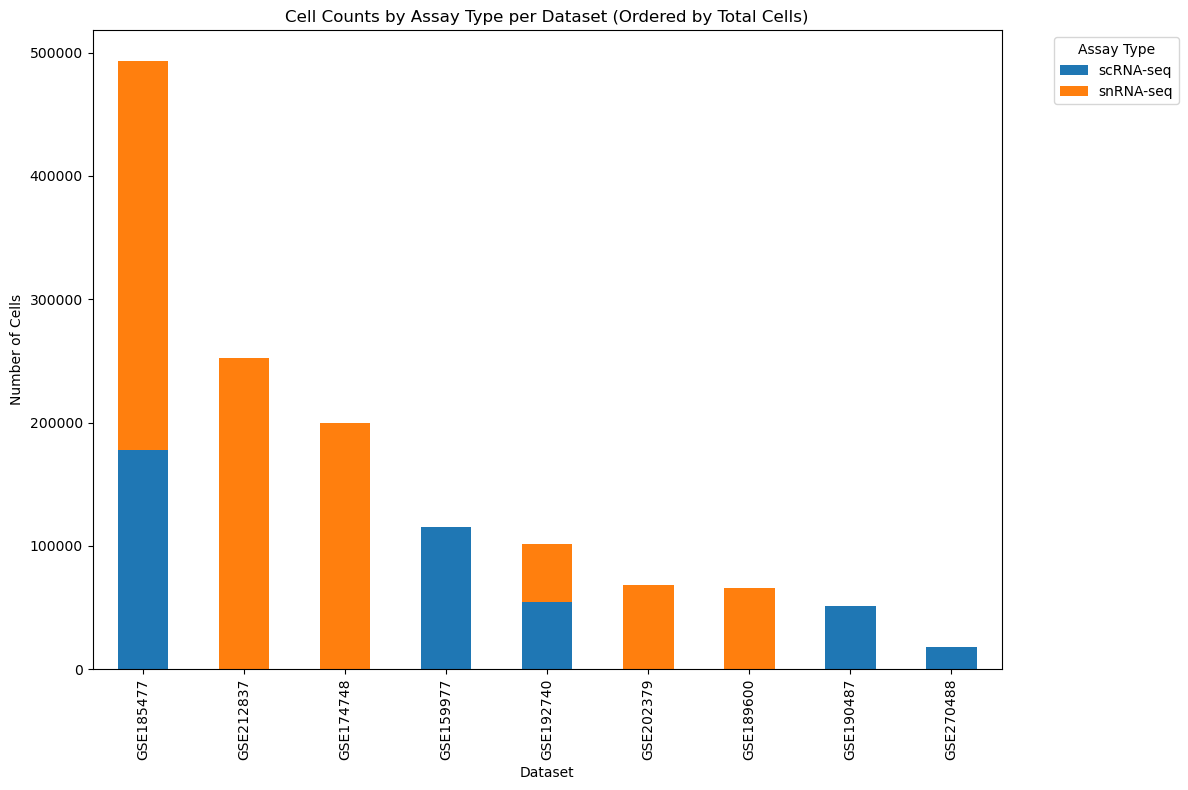

In [6]:
# Due to memory constraints, we cannot merge the large adata objects. Instead, we will create the plots by collecting counts from each adata separately.

# Create stacked bar plot split by "dataset" showing counts of "assay_type", ordered by total cell count
import matplotlib.pyplot as plt

# Collect counts from each adata
all_counts = []
for name, adata in adata_dict.items():
    counts = adata.obs.groupby('assay_type').size().reset_index(name='count')
    counts['dataset'] = name
    all_counts.append(counts)

assay_counts = pd.concat(all_counts).pivot(index='dataset', columns='assay_type', values='count').fillna(0)

# Calculate total cells per dataset
total_cells = assay_counts.sum(axis=1)

# Sort datasets by total cells descending
assay_counts = assay_counts.loc[total_cells.sort_values(ascending=False).index]

# Plot stacked bar
assay_counts.plot(kind='bar', stacked=True, figsize=(12, 8))
plt.xlabel('Dataset')
plt.ylabel('Number of Cells')
plt.title('Cell Counts by Assay Type per Dataset (Ordered by Total Cells)')
plt.legend(title='Assay Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [5]:
for name, adata in adata_dict.items():
    sc.pp.filter_cells(adata, min_genes=100)
    sc.pp.filter_genes(adata, min_cells=3)



c:\Users\ankit\miniconda3\envs\scanpy\Lib\site-packages\anndata\_core\anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
c:\Users\ankit\miniconda3\envs\scanpy\Lib\site-packages\anndata\_core\anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
c:\Users\ankit\miniconda3\envs\scanpy\Lib\site-packages\anndata\_core\anndata.py:1823: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


C:\Users\ankit\AppData\Local\Temp\ipykernel_9888\1222216025.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = adata.obs.groupby('condition').size().reset_index(name='count')
C:\Users\ankit\AppData\Local\Temp\ipykernel_9888\1222216025.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = adata.obs.groupby('condition').size().reset_index(name='count')
C:\Users\ankit\AppData\Local\Temp\ipykernel_9888\1222216025.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=Tru

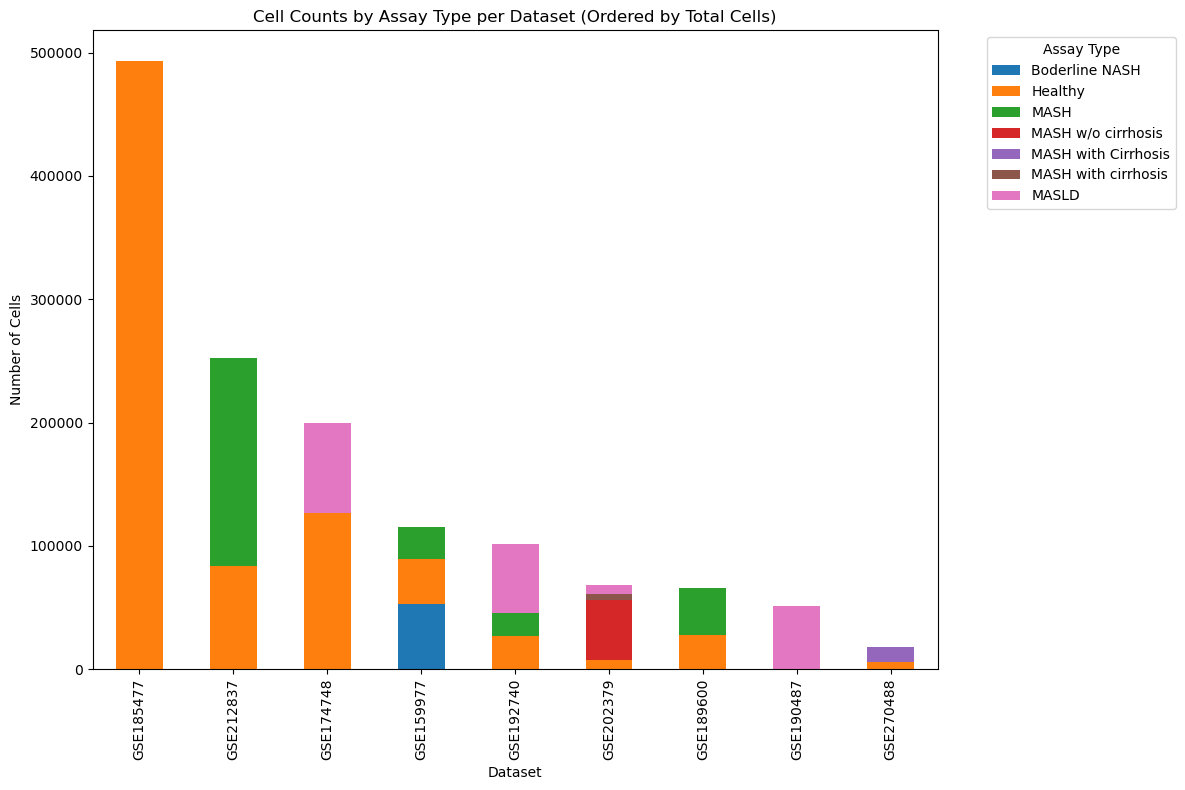

In [8]:
# Due to memory constraints, we cannot merge the large adata objects. Instead, we will create the plots by collecting counts from each adata separately.

# Create stacked bar plot split by "dataset" showing counts of "assay_type", ordered by total cell count
import matplotlib.pyplot as plt

# Collect counts from each adata
all_counts = []
for name, adata in adata_dict.items():
    counts = adata.obs.groupby('condition').size().reset_index(name='count')
    counts['dataset'] = name
    all_counts.append(counts)

assay_counts = pd.concat(all_counts).pivot(index='dataset', columns='condition', values='count').fillna(0)

# Calculate total cells per dataset
total_cells = assay_counts.sum(axis=1)

# Sort datasets by total cells descending
assay_counts = assay_counts.loc[total_cells.sort_values(ascending=False).index]

# Plot stacked bar
assay_counts.plot(kind='bar', stacked=True, figsize=(12, 8))
plt.xlabel('Dataset')
plt.ylabel('Number of Cells')
plt.title('Cell Counts by Assay Type per Dataset (Ordered by Total Cells)')
plt.legend(title='Assay Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

C:\Users\ankit\AppData\Local\Temp\ipykernel_25500\3341405062.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  patient_counts = adata.obs.groupby('condition')['patient_id'].nunique().reset_index(name='unique_patients')
C:\Users\ankit\AppData\Local\Temp\ipykernel_25500\3341405062.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  patient_counts = adata.obs.groupby('condition')['patient_id'].nunique().reset_index(name='unique_patients')
C:\Users\ankit\AppData\Local\Temp\ipykernel_25500\3341405062.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version 

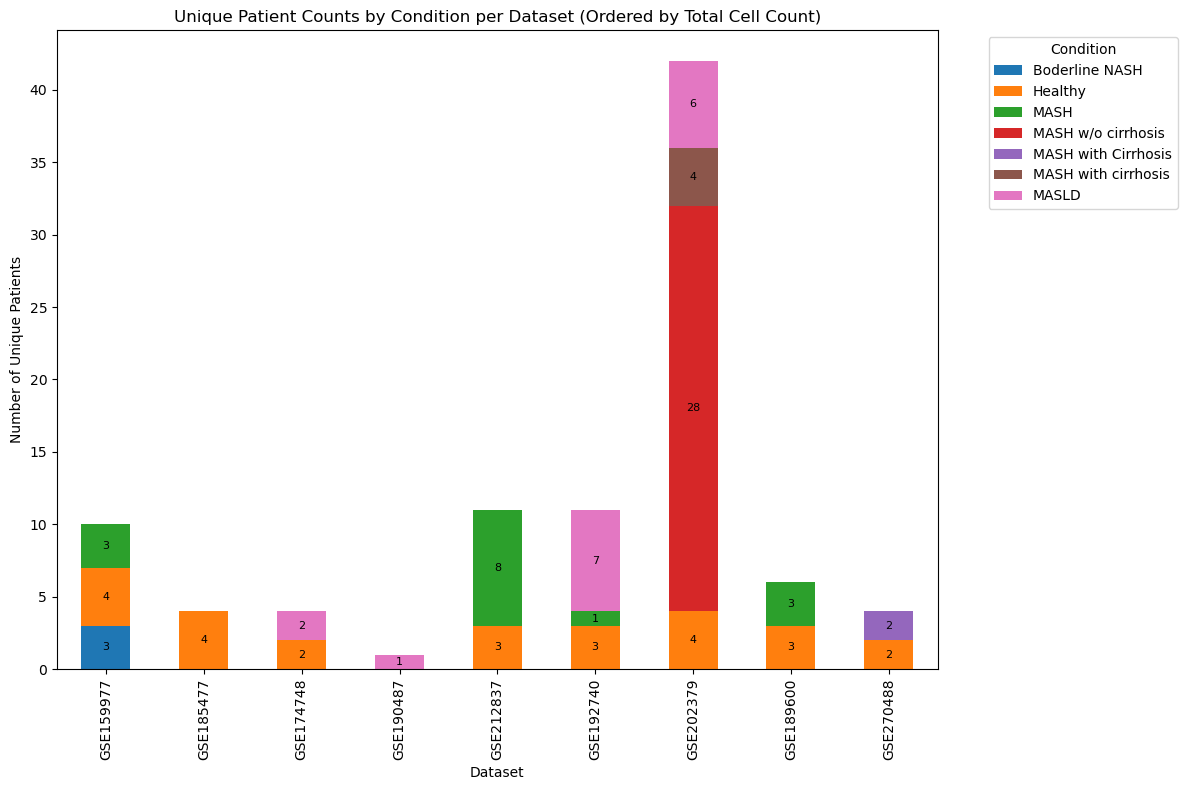

In [4]:
# Create stacked bar plot of unique patient_ids per dataset, split by condition, ordered by total cell count
import matplotlib.pyplot as plt

# Collect unique patient counts per condition from each adata
all_patient_counts = []
dataset_cell_counts = {}
for name, adata in adata_dict.items():
    # Count unique patients per condition
    patient_counts = adata.obs.groupby('condition')['patient_id'].nunique().reset_index(name='unique_patients')
    patient_counts['dataset'] = name
    all_patient_counts.append(patient_counts)
    
    # Store total cell count for ordering
    dataset_cell_counts[name] = adata.n_obs

# Combine all counts
patient_counts_df = pd.concat(all_patient_counts).pivot(index='dataset', columns='condition', values='unique_patients').fillna(0)

# Order datasets by total cell count descending
ordered_datasets = sorted(dataset_cell_counts, key=dataset_cell_counts.get, reverse=True)
patient_counts_df = patient_counts_df.loc[ordered_datasets]

# Plot stacked bar
ax = patient_counts_df.plot(kind='bar', stacked=True, figsize=(12, 8))

# Add value labels on bars
for i in range(len(patient_counts_df)):
    cumulative = 0
    for j, col in enumerate(patient_counts_df.columns):
        value = patient_counts_df.iloc[i, j]
        if value > 0:
            ax.text(i, cumulative + value / 2, f'{int(value)}', ha='center', va='center', fontsize=8)
            cumulative += value

plt.xlabel('Dataset')
plt.ylabel('Number of Unique Patients')
plt.title('Unique Patient Counts by Condition per Dataset (Ordered by Total Cell Count)')
plt.legend(title='Condition', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [12]:
# Print patient count tables

# 1. Patient counts per condition (across all datasets)
total_patient_counts = patient_counts_df.sum(axis=0).reset_index()
total_patient_counts.columns = ['condition', 'total_unique_patients']
print("1. Patient counts per condition (across all datasets):")
print(total_patient_counts.to_string(index=False))
print("\n")

# 2. Patient counts per condition in GSE202379
gse202379_counts = patient_counts_df.loc[['GSE202379']].T.reset_index()
gse202379_counts.columns = ['condition', 'unique_patients']
print("2. Patient counts per condition in GSE202379:")
print(gse202379_counts.to_string(index=False))
print("\n")

# 3. Patient counts per condition in all datasets except GSE202379
other_datasets = patient_counts_df.drop('GSE202379')
other_total_counts = other_datasets.sum(axis=0).reset_index()
other_total_counts.columns = ['condition', 'total_unique_patients']
print("3. Patient counts per condition in all datasets except GSE202379:")
print(other_total_counts.to_string(index=False))

1. Patient counts per condition (across all datasets):
          condition  total_unique_patients
     Boderline NASH                    3.0
            Healthy                   25.0
               MASH                   15.0
 MASH w/o cirrhosis                   28.0
MASH with Cirrhosis                    2.0
MASH with cirrhosis                    4.0
              MASLD                   16.0


2. Patient counts per condition in GSE202379:
          condition  unique_patients
     Boderline NASH              0.0
            Healthy              4.0
               MASH              0.0
 MASH w/o cirrhosis             28.0
MASH with Cirrhosis              0.0
MASH with cirrhosis              4.0
              MASLD              6.0


3. Patient counts per condition in all datasets except GSE202379:
          condition  total_unique_patients
     Boderline NASH                    3.0
            Healthy                   21.0
               MASH                   15.0
 MASH w/o cirrhos

In [18]:
# 1. Patient counts per condition per dataset
# Collect unique patient counts per condition from each adata
all_patient_counts = []
dataset_cell_counts = {}
for name, adata in adata_dict.items():
    # Count unique patients per condition
    patient_counts = adata.obs.groupby('broad_condition')['patient_id'].nunique().reset_index(name='unique_patients')
    patient_counts['dataset'] = name
    all_patient_counts.append(patient_counts)
    
    # Store total cell count for ordering
    dataset_cell_counts[name] = adata.n_obs

# Combine all counts
patient_counts_df = pd.concat(all_patient_counts).pivot(index='dataset', columns='broad_condition', values='unique_patients').fillna(0)

print("1. Patient counts per condition per dataset:")
print(patient_counts_df.to_string())
print("\n")

C:\Users\ankit\AppData\Local\Temp\ipykernel_25500\62901529.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  patient_counts = adata.obs.groupby('broad_condition')['patient_id'].nunique().reset_index(name='unique_patients')
C:\Users\ankit\AppData\Local\Temp\ipykernel_25500\62901529.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  patient_counts = adata.obs.groupby('broad_condition')['patient_id'].nunique().reset_index(name='unique_patients')
C:\Users\ankit\AppData\Local\Temp\ipykernel_25500\62901529.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future ve

1. Patient counts per condition per dataset:
broad_condition  Healthy  MASH  MASLD
dataset                              
GSE159977            4.0   6.0    0.0
GSE174748            2.0   0.0    2.0
GSE185477            4.0   0.0    0.0
GSE189600            3.0   3.0    0.0
GSE190487            0.0   0.0    1.0
GSE192740            3.0   1.0    7.0
GSE202379            4.0  32.0    6.0
GSE212837            3.0   8.0    0.0
GSE270488            2.0   2.0    0.0




C:\Users\ankit\AppData\Local\Temp\ipykernel_25500\62901529.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  patient_counts = adata.obs.groupby('broad_condition')['patient_id'].nunique().reset_index(name='unique_patients')
C:\Users\ankit\AppData\Local\Temp\ipykernel_25500\62901529.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  patient_counts = adata.obs.groupby('broad_condition')['patient_id'].nunique().reset_index(name='unique_patients')
C:\Users\ankit\AppData\Local\Temp\ipykernel_25500\62901529.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future ve

In [19]:
# 1b. Patient counts per broad_condition per dataset for snRNA-seq only
all_patient_counts_snrna = []
dataset_cell_counts_snrna = {}
for name, adata in adata_dict.items():
    if 'assay_type' not in adata.obs.columns:
        print(f"{name} is missing assay_type column")
        continue

    snrna_obs = adata.obs[adata.obs['assay_type'] == 'snRNA-seq']
    patient_counts = snrna_obs.groupby('broad_condition')['patient_id'].nunique().reset_index(name='unique_patients')
    patient_counts['dataset'] = name
    all_patient_counts_snrna.append(patient_counts)
    dataset_cell_counts_snrna[name] = snrna_obs.shape[0]

if all_patient_counts_snrna:
    patient_counts_snrna_df = pd.concat(all_patient_counts_snrna).pivot(index='dataset', columns='broad_condition', values='unique_patients').fillna(0)
else:
    patient_counts_snrna_df = pd.DataFrame()

print("Patient counts per broad_condition per dataset for snRNA-seq only:")
print(patient_counts_snrna_df.to_string())
print("\n")

C:\Users\ankit\AppData\Local\Temp\ipykernel_25500\3138094515.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  patient_counts = snrna_obs.groupby('broad_condition')['patient_id'].nunique().reset_index(name='unique_patients')
C:\Users\ankit\AppData\Local\Temp\ipykernel_25500\3138094515.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  patient_counts = snrna_obs.groupby('broad_condition')['patient_id'].nunique().reset_index(name='unique_patients')
C:\Users\ankit\AppData\Local\Temp\ipykernel_25500\3138094515.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a 

Patient counts per broad_condition per dataset for snRNA-seq only:
broad_condition  Healthy  MASH  MASLD
dataset                              
GSE159977            0.0   0.0    0.0
GSE174748            2.0   0.0    2.0
GSE185477            4.0   0.0    0.0
GSE189600            3.0   3.0    0.0
GSE190487            0.0   0.0    0.0
GSE192740            1.0   1.0    3.0
GSE202379            4.0  32.0    6.0
GSE212837            3.0   8.0    0.0
GSE270488            0.0   0.0    0.0




C:\Users\ankit\AppData\Local\Temp\ipykernel_25500\3138094515.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  patient_counts = snrna_obs.groupby('broad_condition')['patient_id'].nunique().reset_index(name='unique_patients')
C:\Users\ankit\AppData\Local\Temp\ipykernel_25500\3138094515.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  patient_counts = snrna_obs.groupby('broad_condition')['patient_id'].nunique().reset_index(name='unique_patients')


In [14]:
# Summary stats across all datasets
import pandas as pd

# Total cells
total_cells = sum(adata.n_obs for adata in adata_dict.values())

# Unique genes across all datasets
all_genes = set()
for adata in adata_dict.values():
    all_genes.update(adata.var_names)
total_unique_genes = len(all_genes)

# Unique patients across all datasets
all_patients = set()
for adata in adata_dict.values():
    all_patients.update(adata.obs['patient_id'].dropna())
total_unique_patients = len(all_patients)

# Patients per assay type across all datasets
all_obs = []
for name, adata in adata_dict.items():
    obs_subset = adata.obs[['assay_type', 'patient_id']].copy()
    obs_subset['dataset'] = name
    all_obs.append(obs_subset)

combined_obs = pd.concat(all_obs, ignore_index=True)
patients_per_assay = combined_obs.groupby('assay_type')['patient_id'].nunique().reset_index()
patients_per_assay.columns = ['assay_type', 'unique_patients']

print(f"Total cells across all datasets: {total_cells}")
print(f"Total unique genes across all datasets: {total_unique_genes}")
print(f"Total unique patients across all datasets: {total_unique_patients}")
print("\nPatients per assay type across all datasets:")
print(patients_per_assay.to_string(index=False))

Total cells across all datasets: 1366250
Total unique genes across all datasets: 48422
Total unique patients across all datasets: 93

Patients per assay type across all datasets:
assay_type  unique_patients
 scRNA-seq               25
 snRNA-seq               72


In [17]:
# Count patients with age and sex values, and unique gsm_ids across all datasets
patients_with_age = set()
patients_with_sex = set()
all_gsm_ids = set()

for name, adata in adata_dict.items():
    # Patients with age values
    if 'age' in adata.obs.columns:
        age_patients = adata.obs[adata.obs['age'].notna()]['patient_id'].unique()
        patients_with_age.update(age_patients)
    
    # Patients with sex values
    if 'sex' in adata.obs.columns:
        sex_patients = adata.obs[adata.obs['sex'].notna()]['patient_id'].unique()
        patients_with_sex.update(sex_patients)
    
    # Unique gsm_ids
    if 'gsm_id' in adata.obs.columns:
        gsm_ids = adata.obs['gsm_id'].dropna().unique()
        all_gsm_ids.update(gsm_ids)

print(f"Total unique patients with age values: {len(patients_with_age)}")
print(f"Total unique patients with sex values: {len(patients_with_sex)}")
print(f"Total unique gsm_ids: {len(all_gsm_ids)}")

Total unique patients with age values: 74
Total unique patients with sex values: 78
Total unique gsm_ids: 116
